<a href="https://colab.research.google.com/github/Royst97/DSRP_Roy/blob/main/DSRP_2026_Royston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Stuff:

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
df = pd.read_csv("/content/lendingclub_loans_export.csv")

Exploring the Data:

In [11]:
print(df.dtypes, "\n")
print(df.info())

emp_title                            object
emp_length                          float64
state                                object
homeownership                        object
annual_income                       float64
verified_income                      object
debt_to_income                      float64
annual_income_joint                 float64
verification_income_joint            object
debt_to_income_joint                float64
delinq_2y                             int64
months_since_last_delinq            float64
earliest_credit_line                  int64
inquiries_last_12m                    int64
total_credit_lines                    int64
open_credit_lines                     int64
total_credit_limit                    int64
total_credit_utilized                 int64
num_collections_last_12m              int64
num_historical_failed_to_pay          int64
months_since_90d_late               float64
current_accounts_delinq               int64
total_collection_amount_ever    

In [10]:

print(df.shape, "\n")
print(df.columns)

(10000, 55) 

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Cleaning the Data:

In [13]:
loans_df = pd.read_csv("lendingclub_loans_export.csv")

#Change NA values to null
loans_df = loans_df.replace("NA", np.nan)

#Droped join annual income columns (>85% null rate for both)
loans_df.drop(columns = ["annual_income_joint", "verification_income_joint"], inplace = True)

#All loans were 2018, remove year from issue month
loans_df["issue_month"] = pd.to_datetime(loans_df["issue_month"], format="%b-%Y").dt.strftime

#Grade information included in subgrade
loans_df.drop(columns = ["grade"], inplace = True)

loans_df.to_csv("lendingclub_loans_clean.csv")

In [20]:
#Checking for duplicates
print(df.duplicated().sum(), "\n")
print(df.info())

0 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   object 
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  e

In [25]:
df[df["emp_title"].isna()]

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
5,NaN,NaN,KY,OWN,34000.0,Not Verified,6.46,NaN,NaN,NaN,...,A3,Jan-2018,Current,whole,Cash,4256.71,873.13,743.29,129.84,0.0
14,NaN,NaN,FL,MORTGAGE,17000.0,Verified,33.98,NaN,NaN,NaN,...,D3,Jan-2018,Current,whole,Cash,2744.21,454.36,255.79,198.57,0.0
16,NaN,NaN,NV,MORTGAGE,60000.0,Not Verified,31.22,NaN,NaN,NaN,...,D3,Jan-2018,Current,whole,Cash,11374.52,1532.08,625.48,906.60,0.0
23,NaN,NaN,TX,MORTGAGE,40280.0,Verified,7.27,NaN,NaN,NaN,...,A3,Mar-2018,Current,whole,Cash,3323.42,223.71,176.58,47.13,0.0
40,NaN,NaN,MI,MORTGAGE,19000.0,Not Verified,24.79,43000.0,Not Verified,17.15,...,D2,Jan-2018,Current,whole,Cash,9465.30,1261.32,534.70,726.62,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9912,NaN,NaN,MO,OWN,45000.0,Source Verified,24.99,NaN,NaN,NaN,...,B4,Mar-2018,Current,whole,Cash,9525.68,647.78,474.32,173.46,0.0
9932,NaN,NaN,NC,RENT,45000.0,Not Verified,14.93,NaN,NaN,NaN,...,B1,Mar-2018,Current,whole,Cash,18540.06,1899.07,1459.94,439.13,0.0
9941,NaN,NaN,GA,MORTGAGE,25000.0,Verified,28.42,NaN,NaN,NaN,...,B2,Feb-2018,Current,whole,Cash,2731.47,388.37,293.53,94.84,0.0
9975,NaN,NaN,MD,MORTGAGE,95000.0,Source Verified,10.66,NaN,NaN,NaN,...,C3,Mar-2018,Current,whole,Cash,18634.90,2037.09,1365.10,671.99,0.0


Visuals

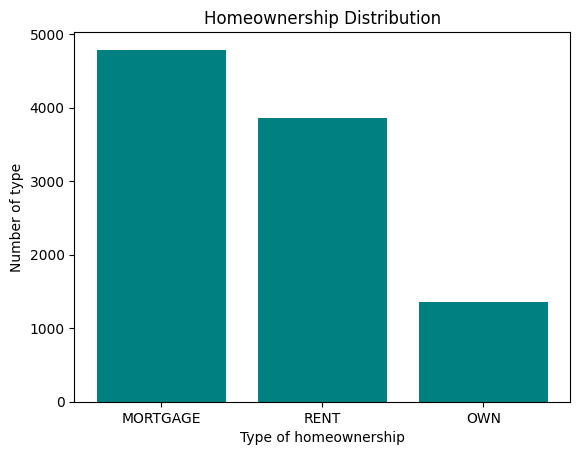

In [32]:
#I might want to do a question based on house ownership compared to something else so

x = df["homeownership"].value_counts().index
y = df["homeownership"].value_counts().values

plt.bar(x, y, color="teal")
plt.title("Homeownership Distribution")
plt.xlabel("Type of homeownership")
plt.ylabel("Number of type")

plt.show()